In [62]:
import sys
print(sys.executable)

c:\Users\Usuario\Documents\Master DS&IA\practice5\.venv\Scripts\python.exe


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

#Carga y head.
df = pd.read_csv(r'C:\Users\Usuario\Documents\Master DS&IA\practice5\data\country_wise_analysis_addiction.csv')
print(df.shape)
display(df.head())
df.info()


(100, 10)


,country,tiktok_minutes_daily,instagram_minutes_daily,attention_span_score,dopamine_dependency_score,sleep_hours,addiction_score,ASI,MHRI,addiction_rank
0,Afghanistan,126.192988,97.339093,81.372327,22.353208,6.914666,58.889380,95.425552,46.163021,35
1,Algeria,124.486204,98.585683,81.410676,22.307189,6.841645,58.548023,94.788858,42.473936,55
2,Angola,118.155100,99.976162,81.822395,21.813126,6.931220,58.986197,96.159267,44.284597,31
3,Argentina,130.618404,104.992073,80.365794,23.561048,6.852418,60.428404,97.295761,46.240974,3
4,Australia,119.451284,101.029686,81.626586,22.048097,6.904793,58.501491,94.954884,46.153129,56


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    100 non-null    str    
 1   tiktok_minutes_daily       100 non-null    float64
 2   instagram_minutes_daily    100 non-null    float64
 3   attention_span_score       100 non-null    float64
 4   dopamine_dependency_score  100 non-null    float64
 5   sleep_hours                100 non-null    float64
 6   addiction_score            100 non-null    float64
 7   ASI                        100 non-null    float64
 8   MHRI                       100 non-null    float64
 9   addiction_rank             100 non-null    int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 7.9 KB


In [64]:
#Ordeno paises por addiction_score
df_addiction_score = df.sort_values(by='addiction_score', ascending=False)
print(df_addiction_score.to_string())

               country  tiktok_minutes_daily  instagram_minutes_daily  attention_span_score  dopamine_dependency_score  sleep_hours  addiction_score        ASI       MHRI  addiction_rank
84            Tanzania            134.673043               106.871909             79.871254                  24.154495     7.258865        60.469459  96.784424  44.571158               1
37           Indonesia            130.531160               104.187705             80.440095                  23.471886     7.119883        60.465271  97.458655  46.048952               2
3            Argentina            130.618404               104.992073             80.365794                  23.561048     6.852418        60.428404  97.295761  46.240974               3
12              Canada            129.338460               102.216999             80.703712                  23.155546     6.884106        60.348169  97.540791  47.764836               4
78               Spain            119.866792               113.14

addiction_score              1.000000
ASI                          0.959825
dopamine_dependency_score    0.883015
tiktok_minutes_daily         0.721436
instagram_minutes_daily      0.555721
sleep_hours                 -0.014115
MHRI                        -0.020210
attention_span_score        -0.883015
addiction_rank              -0.965741
Name: addiction_score, dtype: float64


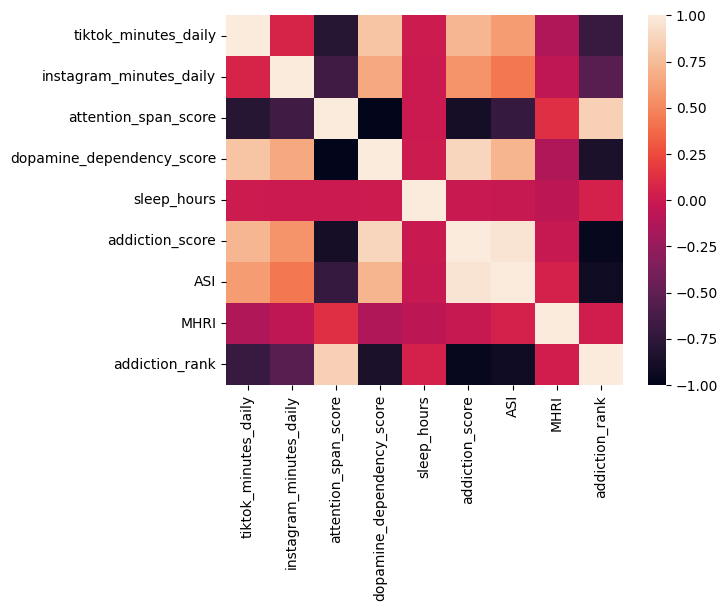

In [65]:
#Correlations with addiction_score
corr_matrix = df.corr(numeric_only=True)

# Filtramos para ver solo la relación con 'nivel_adiccion' y ordenamos de mayor a menor
relacion_adiccion = corr_matrix['addiction_score'].sort_values(ascending=False)

print(relacion_adiccion)
sns.heatmap(corr_matrix)
plt.show()


In [70]:
#Modelo Logistic Regression .Separar variables
X = df.drop(columns=['addiction_score', 'country', 'dopamine_dependency_score', 'addiction_rank'])
y = df['addiction_score']
#Dividimos entrenamiento ( 4 partes: 2X/2Y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    #stratify=y  # Opcional: mantiene la proporción de clases si es clasificación
)

# 1. Instanciar el modelo LinearRegression
model = LinearRegression()

# 2. Entrenar (Ajustar) el modelo
model.fit(X_train, y_train)

# 3. Realizar predicciones
y_pred = model.predict(X_test)

# Obtener métricas de predicción del modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Medio Absoluto): {mae:.2f}")
print(f"Error medio (RMSE): {rmse:.2f}")
print(f"Porcentaje de varianza explicado (R2): {r2:.2f}")

MAE (Error Medio Absoluto): 0.00
Error medio (RMSE): 0.00
Porcentaje de varianza explicado (R2): 1.00


In [ ]:
import joblib

# Guardamos en un diccionario tanto el modelo como la lista exacta de sus columnas
info_modelo = {
    'modelo': model,
    'features': X.columns.tolist() #Son las featuresd guardadas para el entrenamiento
}

# Lo guardamos todo junto en un único archivo
joblib.dump(info_modelo, 'modelo_completo.pkl')
print("¡Modelo guardado con éxito!")

print(X.info())


¡Modelo guardado con éxito!
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tiktok_minutes_daily     100 non-null    float64
 1   instagram_minutes_daily  100 non-null    float64
 2   attention_span_score     100 non-null    float64
 3   sleep_hours              100 non-null    float64
 4   ASI                      100 non-null    float64
 5   MHRI                     100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB
None
